In [14]:
import matplotlib.pyplot as plt
import numpy as np
from nskernel import NonStationaryKernel
from scipy.optimize import fmin_l_bfgs_b, curve_fit
from spleaf import cov, term
import scipy.io as sp
import emcee
import pandas as pd

In [15]:
def planet_injection(t, P, K):
    return K * np.sin(2 * np.pi * t / (P+0.000001))

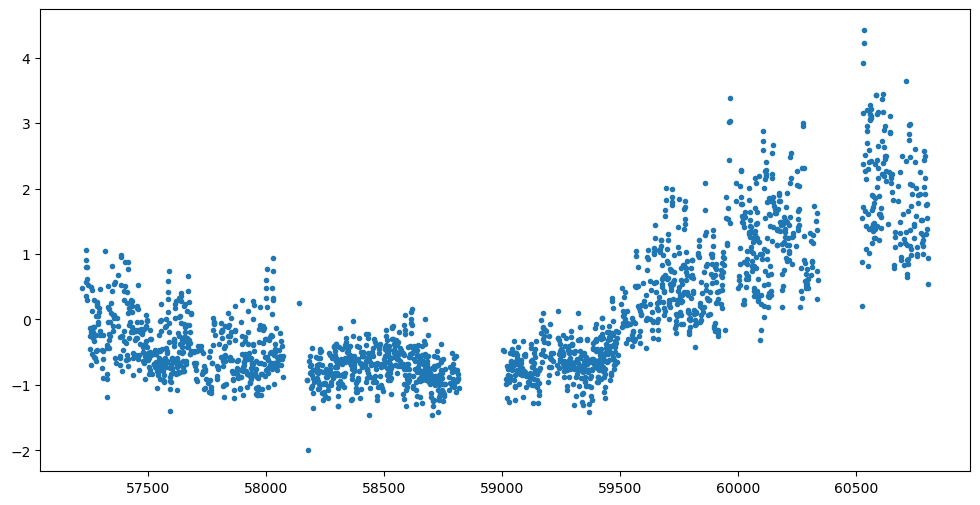

In [16]:
data_rhk = pd.read_csv("Solar Data/Analyse_summary.csv")

data_rhk = data_rhk[data_rhk["flag"] != 1]

arr_len = len(data_rhk)
tt = np.array(data_rhk["jdb"])
tom_f = np.array(data_rhk["tomography_f"])
tom_f_err = np.array(data_rhk["tomography_f_std"])

tom_v = np.array(data_rhk["tomography_v"])
tom_v_err = np.array(data_rhk["tomography_v_std"])

data_rv = pd.read_pickle('Solar Data/Analyse_ccf.p')['CCF_kitcat_mask_Sun']['matching_instrument']['table']
data_rv = data_rv.loc[data_rv.index.isin(data_rhk.index)]

rv = np.array(data_rv['rv'])
erv = np.sqrt(np.array(data_rv['rv_std'])**2 + (np.ones_like(rv) * 0.0005)**2)

# Planet injection

# rv_planet = planet_injection(tt, P=365.25, K=0.0001)
# rv += rv_planet

f_mask = np.where(np.isnan(tom_f)==False)
v_mask = np.where(np.isnan(tom_v)==False)

tom_f = tom_f[f_mask]
tom_f_err = tom_f_err[f_mask]

tom_v = tom_v[v_mask]
tom_v_err = tom_v_err[v_mask]

# Normalisation
rv_mean = np.mean(rv)
rv_std  = np.std(rv)
rv_norm = (rv - rv_mean) / rv_std

tom_f_mean = np.mean(tom_f)
tom_f_std  = np.std(tom_f)
tom_f_norm = (tom_f - tom_f_mean) / tom_f_std

tom_v_mean = np.mean(tom_v)
tom_v_std  = np.std(tom_v)
tom_v_norm = (tom_v - tom_v_mean) / tom_v_std

# # ERROR normalization using SAME scaling as parent data
erv_norm     = erv / rv_std
tom_f_err_norm = tom_f_err / tom_f_std
tom_v_err_norm = tom_v_err / tom_v_std

T = [tt,tt[f_mask],tt[v_mask]]
Y = [rv_norm,tom_f_norm,tom_v_norm]
Yerr = [erv_norm,tom_f_err_norm,tom_v_err_norm]
t_full, y_full, yerr_full, series_index = cov.merge_series(T,Y,Yerr)



plt.figure(figsize=(12, 6))
plt.plot(tt, rv_norm, ".", label="Normalized RV")

In [17]:
def alpha(t, pcyc, phi, k):
    # constraint |k| <= 1/3
    # k = (1.0 / 3.0) * np.tanh(k_raw)
    x = (2.0 * np.pi / pcyc) * t + phi

    fc = np.sin(x + k * np.sin(x))  # in [-1, 1]

    # linear normalization to [C, 1]
    return fc
    # return ((1.0 - c) / 2.0) * (fc + 1.0) + c

def alpha_grad(t, pcyc, phi, k):
    
    omega = 2.0 * np.pi / pcyc
    x = omega * t + phi

    # k is provided directly (assumed already constrained to |k| <= 1/3)
    # (previously: k = (1.0 / 3.0) * np.tanh(k_raw))

    inner = x + k * np.sin(x)
    s_inner = np.sin(inner)
    c_inner = np.cos(inner)

    # scale = (1.0 - c) / 2.0

    # d(inner)/dx
    d_inner_dx = 1.0 + k * np.cos(x)

    # d alpha / d s
    # d_alpha_ds = scale

    # chain: d alpha / d inner
    # d_alpha_dinner = d_alpha_ds * c_inner
    d_alpha_dinner =  c_inner

    grads = {}

    # ----- derivative wrt phi -----
    # dx/dphi = 1
    grads['phi'] = d_alpha_dinner * d_inner_dx

    # ----- derivative wrt pcyc -----
    # omega = 2π/pcyc
    domega_dp = -2.0 * np.pi / (pcyc ** 2)
    dx_dp = domega_dp * t
    grads['pcyc'] = d_alpha_dinner * d_inner_dx * dx_dp

    # ----- derivative wrt k -----
    # k is the input directly, so dk/dk = 1
    d_inner_dk = np.sin(x)
    grads['k'] = d_alpha_dinner * d_inner_dk

    # ----- derivative wrt c -----
    # alpha = scale*(s+1) + c
    # scale = (1-C)/2
    # d alpha / dC = -(1/2)*(s+1) + 1
    # grads['c'] = -0.5 * (s_inner + 1.0) + 1.0

    return grads

In [18]:
class MultiSeriesKernel(term.MultiSeriesKernel):
  def _grad_param(self, grad_dU=None, grad_dV=None):
    if grad_dU is not None or grad_dV is not None:
      raise NotImplementedError()
    return super()._grad_param()

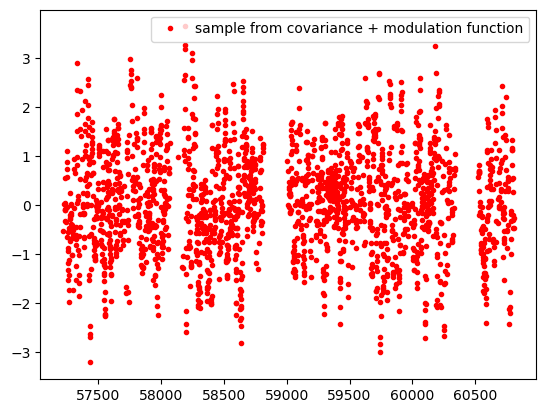

In [19]:
from scipy.optimize import fmin_l_bfgs_b

stds = [np.std(y) for y in Y]
sig = np.var(y_full)   
prot = 28.0
Q = 1.3

rvjit = 0.1*stds[0]
tom_fjit = 0.1*stds[1]
tom_vjit = 0.1*stds[2]

# a1, a2, c, pcyc = 0.5, -6.1, 2.0, 2500.0

pcyc, phi, k = 8000.0, -np.pi/2, 0.1


C = cov.Cov(
  t_full,
  err=term.Error(yerr_full),
  rv_jit=term.InstrumentJitter(series_index[0], rvjit),
  tom_f_jit=term.InstrumentJitter(series_index[1], tom_fjit),
  tom_v_jit=term.InstrumentJitter(series_index[2], tom_vjit),
  rot = MultiSeriesKernel(term.SHOKernel(sig,prot, Q), series_index, 
        np.ones(3) * stds, 
        np.array([stds[0], 0.0, 0.0])
    ),
  )

fc = alpha(t_full[series_index[0]], pcyc, phi, k)
drawn_sample = C.sample()[series_index[0]]

plt.plot(t_full[series_index[0]], drawn_sample, ".", color="red", label="sample from covariance + modulation function")
# plt.plot(t_full[series_index[0]], fc*0.05, ".", color="blue", label="modulation function")
plt.legend()



In [20]:
rvjit_max = stds[0]
rhkjit_max = 5*stds[1]

prot_min = 17.0
prot_max = 30.0
Q_min = 0.7
Q_max = 1.7

alpha_0_max = 5*stds[0]
alpha_1_max = 5*stds[1]
beta_0_max  = 5*stds[0]
beta_1_max  = 5*stds[1]

pcyc_min = 7000.0
pcyc_max = 9000.0

gamma_0_max = 5*stds[0]
gamma_1_max = 5*stds[1]

bounds_list = [
    (0.0, rvjit_max),                     # rv_jit.sig
    (0.0, rhkjit_max),                     # rhk_jit.sig
    (0.0, rhkjit_max),
    (prot_min, prot_max),                 # rot.P0 (period)
    (Q_min, Q_max),                      # rot.Q (quality factor)
    (0, alpha_0_max),         # rot.alpha_0 (set lower bound to zero)
    (-alpha_1_max, alpha_1_max),         # rot.alpha_1
    (-alpha_1_max, alpha_1_max),  
    (-beta_0_max, beta_0_max),         # rot.beta_0      # rot.beta_1
    (pcyc_min, pcyc_max),
    (0,np.pi*2),
    (-0.4,0.4),  # k
    # (0.01,0.99), 
    (0.0, gamma_0_max*2+2),         # rot.gamma_0
    (0.0, gamma_1_max*2+2),         # rot.gamma_1
    (0.0, gamma_1_max*2+2),
    (-gamma_0_max, gamma_0_max),         # delta_0 (offset for series 0)
    (-gamma_1_max, gamma_1_max),    
    (-gamma_1_max, gamma_1_max)  
    # (350.0, 380.0),                         # P_planet
    # (0.00005, 0.0005)                          # K_planet

]

C.param

['rv_jit.sig',
 'tom_f_jit.sig',
 'tom_v_jit.sig',
 'rot.sig',
 'rot.P0',
 'rot.Q',
 'rot.alpha_0',
 'rot.alpha_1',
 'rot.alpha_2',
 'rot.beta_0',
 'rot.beta_1',
 'rot.beta_2']

In [21]:
map_sample = np.load("sun_map_sample.npy")
          
fitted = [k for k, key in enumerate(C.param) if key != 'rot.sig' and key != "rot.beta_1" and key != "rot.beta_2"]  
params = [C.param[k] for k in fitted]
x0 = C.get_param(params)
x0 = np.append(x0,[map_sample[2],map_sample[3],map_sample[4],0.0,0.0,0.0,0.0,0.0,0.0])  # add pcyc, phi, k, gamma_0, gamma_1, delta_0, delta_1, planet_p, planet_k

def negloglike(x, y, C):
  
  C.set_param(x[:len(params)], params)
  fc = alpha(t_full, x[9],x[10],x[11])
  # fc_unnorm = (fc - x[10]) / ((1.0 - x[10]) / 2.0) - 1
  fc_grads = alpha_grad(t_full ,x[9],x[10],x[11])
  y_model = y.copy()
  y_model[series_index[0]] -= (x[-6]*fc[series_index[0]] + x[-3])
  y_model[series_index[1]] -= (x[-5]*fc[series_index[1]] + x[-2])
  y_model[series_index[2]] -= (x[-4]*fc[series_index[1]] + x[-1])
  # y_model[series_index[0]] -= (planet_injection(t_full[series_index[0]], x[-2], x[-1]) )/rv_std

  # gradient§
  nll = -C.loglike(y_model)

  lg = C.loglike_grad()
  dL_dy = np.asarray(lg[0]).reshape(-1)      # shape (N_total,) 
  dL_dparams = np.asarray(lg[1]).reshape(-1) # shape (12,)      

  base_grad = - dL_dparams[fitted]  

  # gradients wrt gamma (scale of fc)
  grad_gamma_0 = np.sum(dL_dy[series_index[0]] * fc[series_index[0]])
  grad_gamma_1 = np.sum(dL_dy[series_index[1]] * fc[series_index[1]])
  grad_gamma_2 = np.sum(dL_dy[series_index[2]] * fc[series_index[2]])
  # gradients wrt delta (additive offsets)
  grad_delta_0 = np.sum(dL_dy[series_index[0]])
  grad_delta_1 = np.sum(dL_dy[series_index[1]])
  grad_delta_2 = np.sum(dL_dy[series_index[2]])

  grad_pcyc = np.sum(dL_dy[series_index[0]] * x[-6] * fc_grads['pcyc'][series_index[0]]) + np.sum(dL_dy[series_index[1]] * x[-5] * fc_grads['pcyc'][series_index[1]]) + np.sum(dL_dy[series_index[2]] * x[-4] * fc_grads['pcyc'][series_index[2]])
  grad_phi = np.sum(dL_dy[series_index[0]] * x[-6] * fc_grads['phi'][series_index[0]]) + np.sum(dL_dy[series_index[1]] * x[-5] * fc_grads['phi'][series_index[1]]) + np.sum(dL_dy[series_index[2]] * x[-4] * fc_grads['phi'][series_index[2]])
  grad_k_alpha = np.sum(dL_dy[series_index[0]] * x[-6] * fc_grads['k'][series_index[0]]) + np.sum(dL_dy[series_index[1]] * x[-5] * fc_grads['k'][series_index[1]]) + np.sum(dL_dy[series_index[2]] * x[-4] * fc_grads['k'][series_index[2]])
  # grad_c = np.sum(dL_dy[series_index[0]] * x[-4] * fc_grads['c'][series_index[0]]) + np.sum(dL_dy[series_index[1]] * x[-3] * fc_grads['c'][series_index[1]])


  # grad_planet_p = np.sum(dL_dy[series_index[0]] * (1/rv_std)*(-x[-1] * 2 * np.pi * t_full[series_index[0]] / ((x[-2]+0.000001)**2) * np.cos(2 * np.pi * t_full[series_index[0]] / (x[-2]+0.000001)))) 
  # grad_planet_k = np.sum(dL_dy[series_index[0]] * (1/rv_std)*(np.sin(2 * np.pi * t_full[series_index[0]] / (x[-2]+0.000001))))

  nll_grad = np.concatenate([np.asarray(base_grad).ravel(), np.array([grad_pcyc, grad_phi, grad_k_alpha, grad_gamma_0, grad_gamma_1, grad_gamma_2, grad_delta_0, grad_delta_1, grad_delta_2])])

  # nll_grad = -C.loglike_grad()[1][fitted]

  return (nll, nll_grad)


result = fmin_l_bfgs_b(negloglike, x0, args=(y_full, C), bounds=bounds_list)
xbest = result[0]

C.set_param(xbest[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])
C.set_param([0.0], ['rot.beta_2'])


print(params)
print(xbest)

['rv_jit.sig', 'tom_f_jit.sig', 'tom_v_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.alpha_2', 'rot.beta_0']
[ 0.00000000e+00  4.22837089e-02  7.72014968e-01  2.03749958e+01
  7.00000000e-01  4.76403226e-01  3.95680287e-01 -1.20477648e-01
  4.40236687e-01  7.88475735e+03  1.94497333e+00 -2.03906105e-01
  2.79032042e+00  3.03285481e+00  1.47694003e+00  1.87219572e+00
  2.03191168e+00  9.97021127e-01]


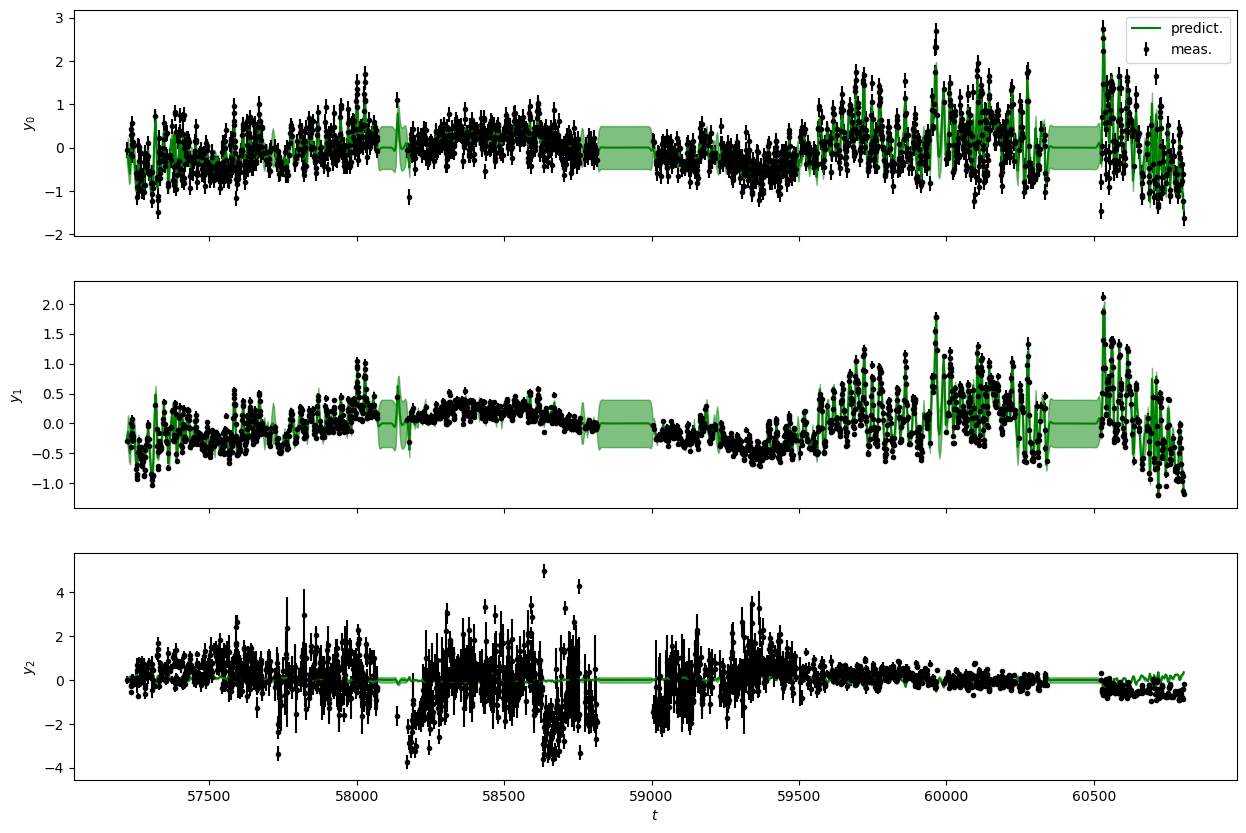

In [22]:

tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(3, 1, sharex=True, figsize=(15, 10))


for k in range(3):
  # Predict time series k
  C.kernel['rot'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)

  fc = alpha(t_full, xbest[9],xbest[10],xbest[11])
  # fc_unnorm = (fc - xbest[10]) / ((1.0 - xbest[10]) / 2.0) - 1
  y_model = y_full.copy()
  y_model[series_index[0]] -= (xbest[-6]*fc[series_index[0]] + xbest[-3])
  y_model[series_index[1]] -= (xbest[-5]*fc[series_index[1]] + xbest[-2])
  y_model[series_index[2]] -= (xbest[-4]*fc[series_index[2]] + xbest[-1])
  # y_model[series_index[0]] -= (planet_injection(t_full[series_index[0]], xbest[-2], xbest[-1]))/rv_std

  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  # if k == 0:
  #   res_rv = Y[k] - mu_res
  # else:
  #   res_rhk = Y[k] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(xbest[-6]*fc[series_index[0]]+xbest[-3]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(xbest[-5]*fc[series_index[1]]+xbest[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 2:
    ax.errorbar(T[k], Y[k]-(xbest[-4]*fc[series_index[2]]+xbest[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

In [23]:
import emcee

def log_prior(theta):
    # unpack theta (added delta_0, delta_1 as final two entries)
    # rv_jit, rhk_jit, pcyc, phi, k_raw, c, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_beta_0, gamma_0, gamma_1, delta_0, delta_1 = theta
    rv_jit, f_jit, v_jit, rot_P0, rot_Q, rot_alpha_0, rot_alpha_1, rot_alpha_2, rot_beta_0, pcyc, phi, k, gamma_0, gamma_1, gamma_2, delta_0, delta_1, delta_2 = theta
    phi = phi % (2*np.pi)
    if 0.0 < rv_jit < rvjit_max and 0.0 < f_jit < rhkjit_max and 0.0 < v_jit < rhkjit_max and pcyc_min < pcyc < pcyc_max and 0 < phi < np.pi*2 and -0.4 < k < 0.4 and prot_min < rot_P0 < prot_max and Q_min < rot_Q < Q_max and 0.0 < rot_alpha_0 < alpha_0_max and -alpha_1_max < rot_alpha_1 < alpha_1_max and -alpha_1_max < rot_alpha_2 < alpha_1_max and -beta_0_max < rot_beta_0 < beta_0_max and 0.0 < gamma_0 < gamma_0_max and 0.0 < gamma_1 < gamma_0_max and 0.0 < gamma_2 < gamma_0_max and -gamma_0_max < delta_0 < gamma_0_max and -gamma_0_max < delta_1 < gamma_0_max and -gamma_0_max < delta_2 < gamma_0_max:
        return 0.0
    return -np.inf

def log_probability(theta, y, C):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + -1*negloglike(theta, y, C)[0]

x0 = xbest.copy()
# x0 = map_sample[[0,1,6,7,8,9,10]]
print(x0)
print(log_prior(x0))    

# x0 = [0.03, 0.2, 1500.0, 0.015, 4.0, 4.0, 4.0]
ndim = len(x0)
pos = x0 + 1e-4 * np.random.randn(ndim*3, ndim)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(y_full, C)
)
sampler.run_mcmc(pos, 2000, progress=True);



[ 0.00000000e+00  4.22837089e-02  7.72014968e-01  2.03749958e+01
  7.00000000e-01  4.76403226e-01  3.95680287e-01 -1.20477648e-01
  4.40236687e-01  7.88475735e+03  1.94497333e+00 -2.03906105e-01
  2.79032042e+00  3.03285481e+00  1.47694003e+00  1.87219572e+00
  2.03191168e+00  9.97021127e-01]
-inf


  0%|          | 0/2000 [00:00<?, ?it/s]/opt/anaconda3/envs/sleaf/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [06:47<00:00,  4.90it/s]


['rv_jit.sig', 'tom_f_jit.sig', 'tom_v_jit.sig', 'rot.P0', 'rot.Q', 'rot.alpha_0', 'rot.alpha_1', 'rot.alpha_2', 'rot.beta_0', 'pcyc', 'phi', 'k', 'gamma_0', 'gamma_1', 'gamma_2', 'delta_0', 'delta_1', 'delta_2']


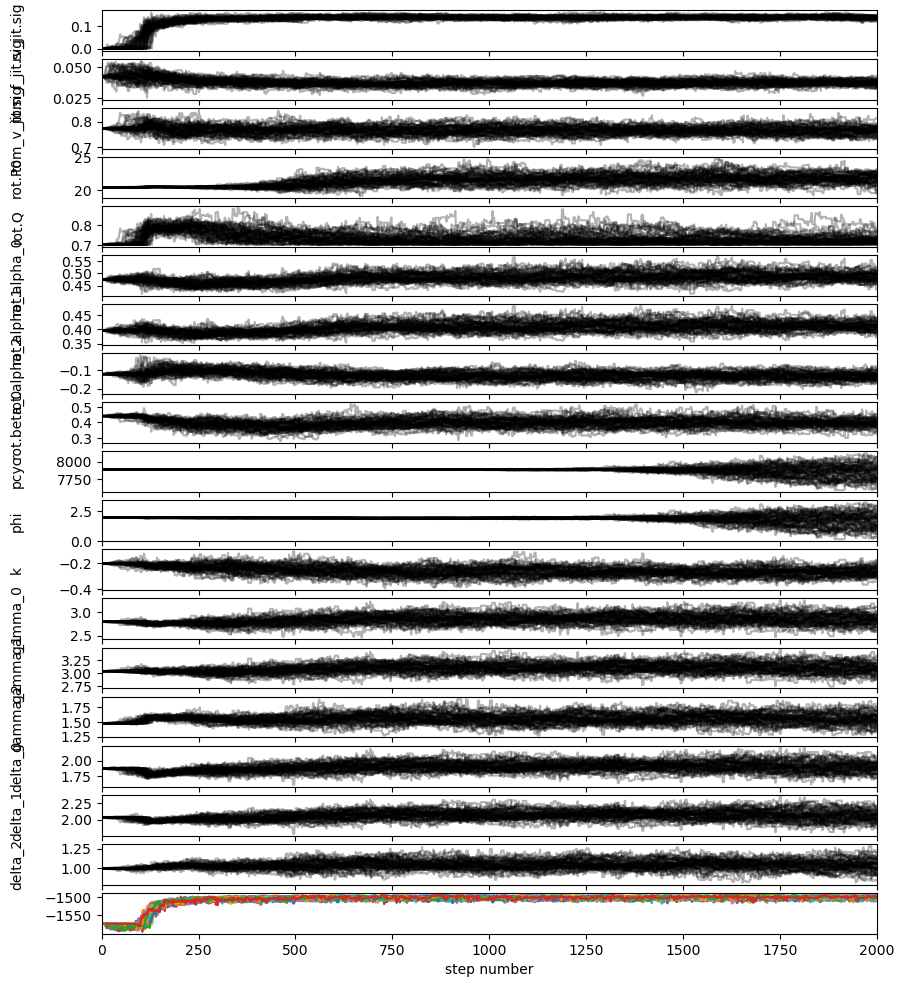

In [29]:
# ig, axes = plt.subplots(13, figsize=(10, 12), sharex=True)
ig, axes = plt.subplots(len(params) + 10, figsize=(10, 12), sharex=True)
samples = sampler.get_chain()

# labels = params + ['gamma_0', 'gamma_1', 'delta_0', 'delta_1']
labels = params + ['pcyc','phi','k','gamma_0', 'gamma_1', 'gamma_2', 'delta_0', 'delta_1', 'delta_2']
print(labels)
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

logp = sampler.get_log_prob(flat=False)
axes[-1].plot(logp)

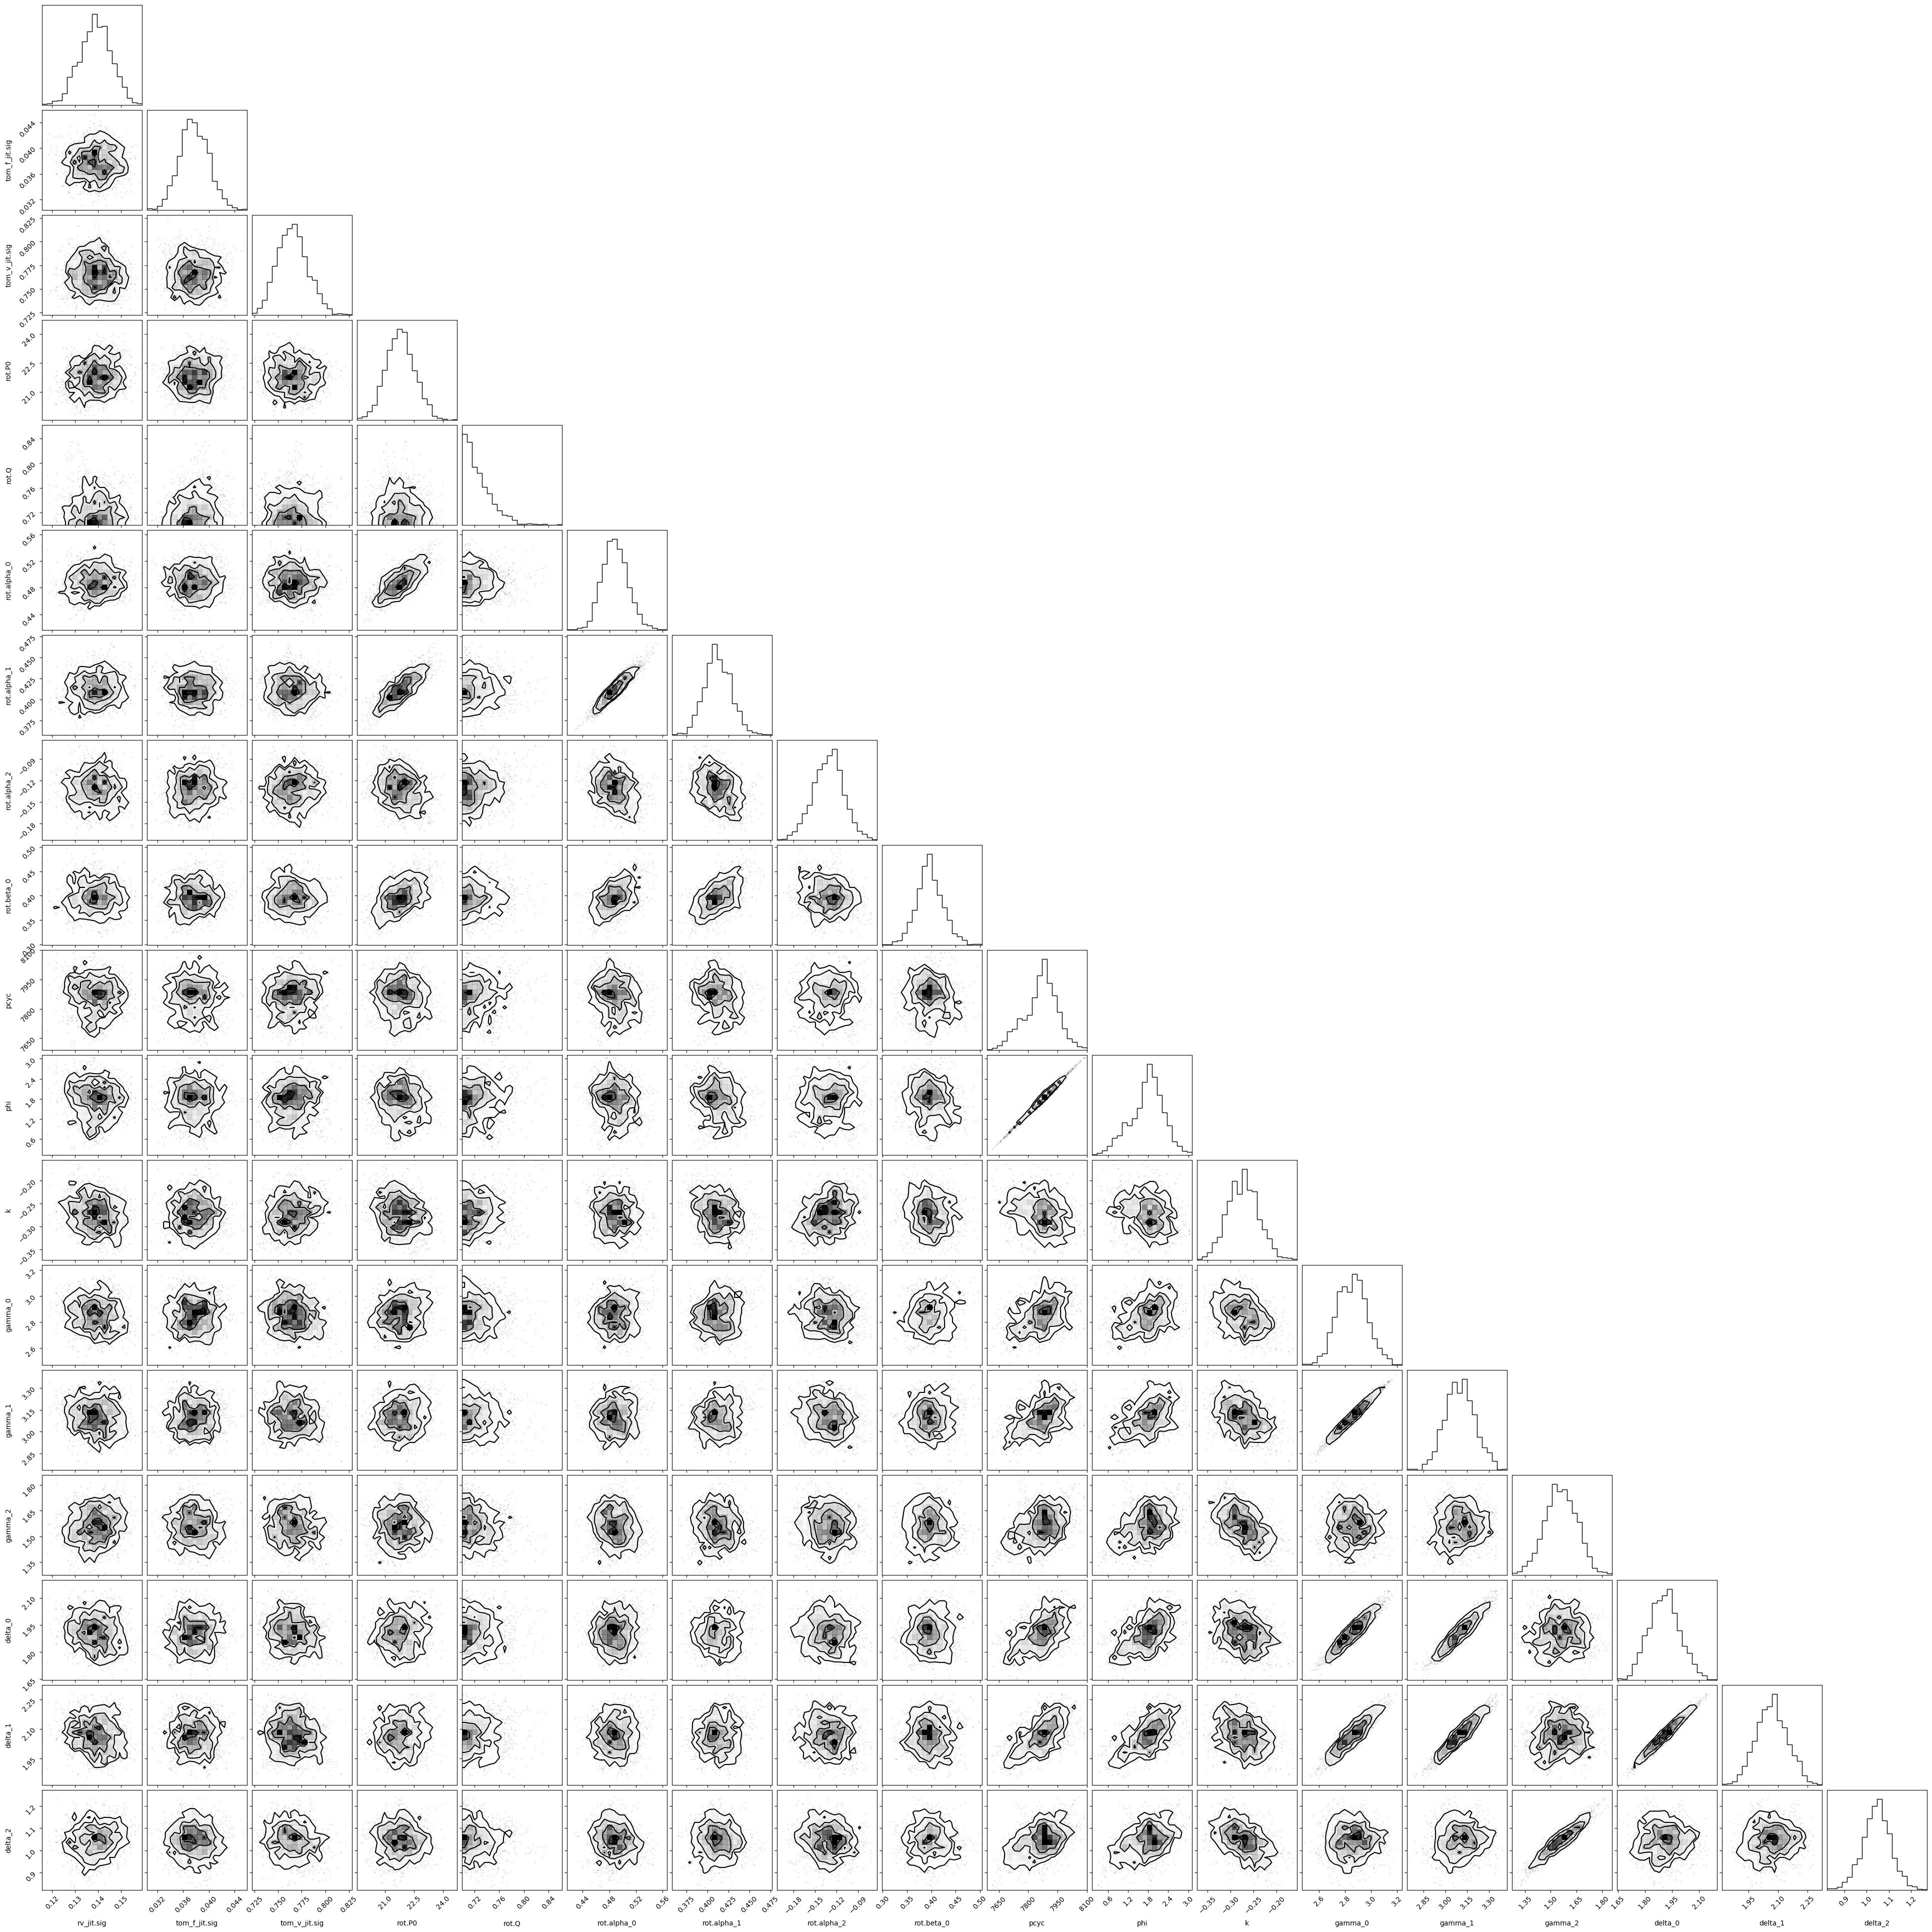

In [30]:
import corner

flat_samples = sampler.get_chain(discard=1500, thin=15, flat=True)

fig = corner.corner(
    flat_samples, labels=labels
);


In [31]:
burn = 1500   
thin = 1

flat_samples = sampler.get_chain(discard=burn, thin=thin, flat=True)   # shape (n_samples, ndim)
flat_logp    = sampler.get_log_prob(discard=burn, thin=thin, flat=True) # shape (n_samples,)

finite_mask = np.isfinite(flat_logp)
flat_samples = flat_samples[finite_mask]
flat_logp    = flat_logp[finite_mask]

map_idx = np.argmax(flat_logp)
map_sample = flat_samples[map_idx]
map_logp = flat_logp[map_idx]

print("MAP index (in flattened, post-burn chain):", map_idx)
print("MAP log-posterior:", map_logp)
print("MAP sample (theta):", map_sample)

# np.save("sun_map_sample.npy", map_sample)

MAP index (in flattened, post-burn chain): 15240
MAP log-posterior: -1493.8590712097684
MAP sample (theta): [ 1.40437791e-01  3.74506817e-02  7.64644815e-01  2.16570363e+01
  7.18639653e-01  4.80972328e-01  4.04036754e-01 -1.14448618e-01
  3.92073134e-01  7.84813218e+03  1.68167759e+00 -2.61420746e-01
  2.81197378e+00  3.06490988e+00  1.56286406e+00  1.88373849e+00
  2.04775518e+00  1.03660941e+00]


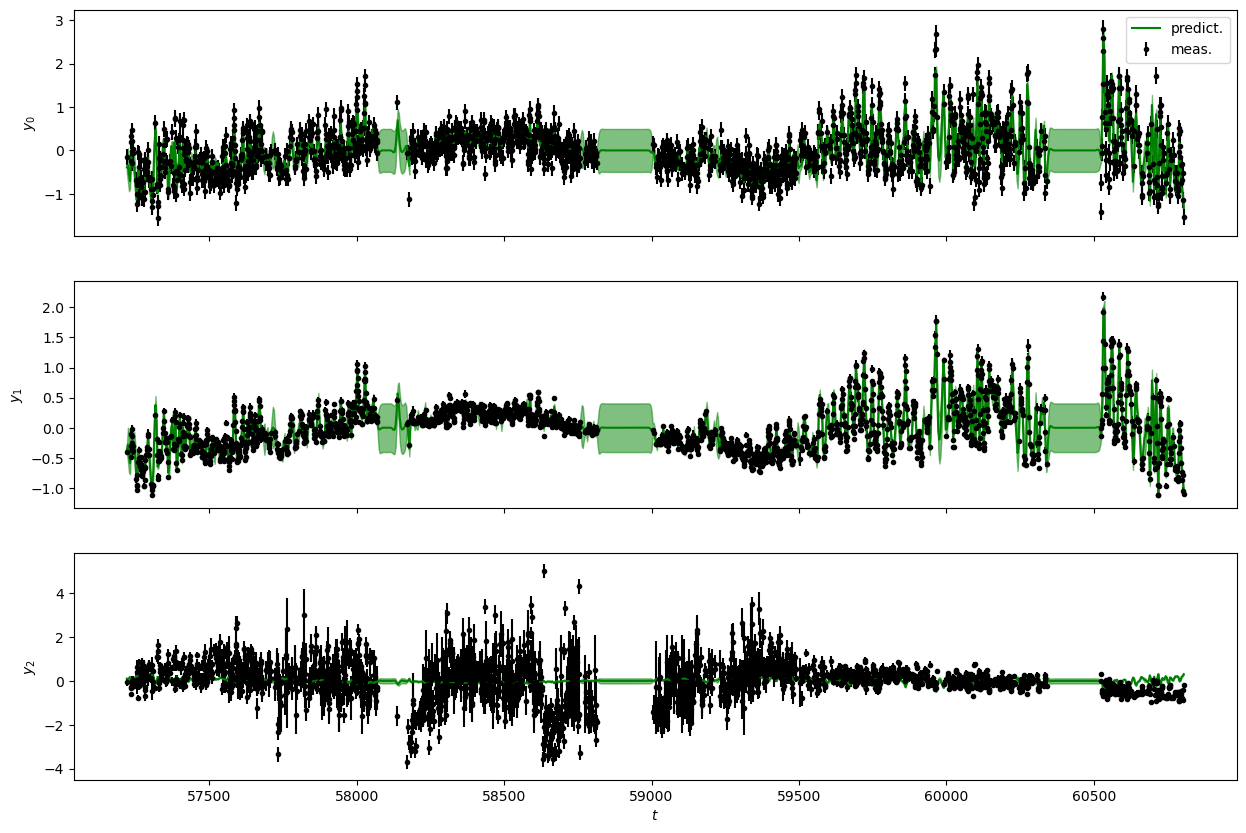

In [41]:
C.set_param(map_sample[:len(params)], params)
C.set_param([0.0], ['rot.beta_1'])
C.set_param([0.0], ['rot.beta_2'])
C.set_param([np.var(y_full)], ['rot.sig'])


tsmooth = np.linspace(np.min(t_full), np.max(t_full), 1000)
_, axs = plt.subplots(3, 1, sharex=True, figsize=(15, 10))


for k in range(3):
  # Predict time series k
  C.kernel['rot'].set_conditional_coef(series_id=k)
  # C.kernel['rot'].set_conditional_coef(series_id=k)

  fc = alpha(t_full, map_sample[9],map_sample[10],map_sample[11])
  # fc_unnorm = (fc - xbest[10]) / ((1.0 - xbest[10]) / 2.0) - 1
  y_model = y_full.copy()
  y_model[series_index[0]] -= (map_sample[-6]*fc[series_index[0]] + map_sample[-3])
  y_model[series_index[1]] -= (map_sample[-5]*fc[series_index[1]] + map_sample[-2])
  y_model[series_index[2]] -= (map_sample[-4]*fc[series_index[2]] + map_sample[-1])
  # y_model[series_index[0]] -= (planet_injection(t_full[series_index[0]], map_sample[-2], map_sample[-1]))/rv_std

  mu, var = C.conditional(y_model, tsmooth, calc_cov='diag')
  mu_res, _ = C.conditional(y_model, T[k], calc_cov='diag')
  if k == 0:
    res_rv = y_model[series_index[k]] - mu_res
  elif k == 1:
    res_tom_f = y_model[series_index[k]] - mu_res
  else:
    res_tom_v = y_model[series_index[k]] - mu_res
  # Plot
  
  ax = axs[k]
  if k ==0 :
    ax.errorbar(T[k], Y[k]-(map_sample[-6]*fc[series_index[0]]+map_sample[-3]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 1:
    ax.errorbar(T[k], Y[k]-(map_sample[-5]*fc[series_index[1]]+map_sample[-2]), Yerr[k], fmt='.', color='k', label='meas.')
  if k == 2:
    ax.errorbar(T[k], Y[k]-(map_sample[-4]*fc[series_index[2]]+map_sample[-1]), Yerr[k], fmt='.', color='k', label='meas.')
  ax.fill_between(tsmooth,
    mu - np.sqrt(var),
    mu + np.sqrt(var),
    color='g',
    alpha=0.5)
  ax.plot(tsmooth, mu, 'g', label='predict.')
  ax.set_ylabel(f'$y_{k}$')
ax.set_xlabel('$t$')
axs[0].legend()

plt.show()

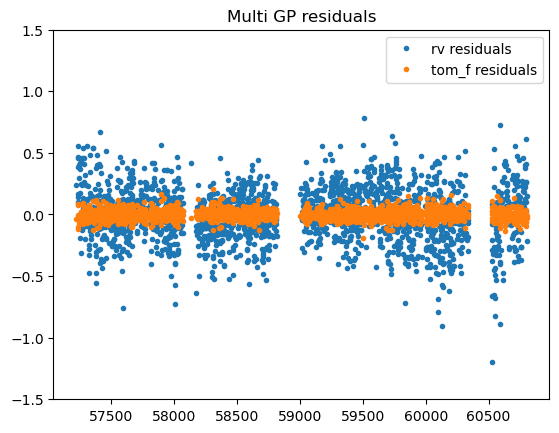

In [43]:
plt.figure()
plt.title("Multi GP residuals")
plt.plot(T[0], res_rv, ".", label='rv residuals')
plt.plot(T[1], res_tom_f, ".", label='tom_f residuals')
# plt.plot(T[2], res_tom_v, ".", label='tom_v residuals')
plt.ylim(-1.5,1.5)
plt.legend()
plt.show()